In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

def download_close(ticker, start="2018-01-01"):
    df = yf.download(ticker, start=start, auto_adjust=True, progress=False)
    if df.empty:
        raise RuntimeError(f"No data returned for {ticker} — check ticker/network/rate limits")
    return df["Close"]

pep = download_close("PEP")
ko = download_close("KO")

raw = pd.concat([pep, ko], axis=1, keys=["PEP", "KO"]).dropna()
print(raw.shape)   # sanity check — should be a few thousand rows, not 0

y = np.log(raw["PEP"]).values.ravel()
x = np.log(raw["KO"]).values.ravel()
dates = raw.index
n = len(y)
print(n)

(184, 2)
184


In [36]:
def run_kalman(y, x, delta, R, init_theta=None, init_P=None):
    n = len(y)
    Q = delta / (1 - delta) * np.eye(2)

    theta = np.zeros(2) if init_theta is None else init_theta.copy()
    P = np.eye(2) if init_P is None else init_P.copy()

    betas = np.zeros(n)
    alphas = np.zeros(n)
    e = np.zeros(n)      # innovation (the tradeable spread)
    S = np.zeros(n)      # innovation variance

    for t in range(n):
        H = np.array([x[t], 1.0])

        # predict
        theta_pred = theta          # random walk: F = I
        P_pred = P + Q

        # innovation (uses YESTERDAY's theta against TODAY's prices)
        e_t = y[t] - H @ theta_pred
        S_t = H @ P_pred @ H.T + R
        S_t = max(S_t, 1e-12)

        # update
        K = P_pred @ H / S_t
        theta = theta_pred + K * e_t
        P = P_pred - np.outer(K, H) @ P_pred

        betas[t], alphas[t] = theta
        e[t], S[t] = e_t, S_t

    return betas, alphas, e, S, theta, P

In [37]:
def initial_R(y, x, window=60):
    yw, xw = y[:window], x[:window]
    beta0 = np.sum((xw - xw.mean()) * (yw - yw.mean())) / np.sum((xw - xw.mean())**2)
    alpha0 = yw.mean() - beta0 * xw.mean()
    resid = yw - (beta0 * xw + alpha0)
    return max(resid.var(ddof=2), 1e-10)

R = initial_R(y, x)

In [38]:
def calibrate_delta(y, x, R, burn_in=60, deltas=np.logspace(-3, -9, 25)):
    best_delta, best_gap = None, np.inf
    for d in deltas:
        _, _, e, S, _, _ = run_kalman(y, x, d, R)
        realized = np.std(e[burn_in:])
        predicted = np.mean(np.sqrt(S[burn_in:]))
        if predicted <= 0:
            continue
        gap = abs(np.log(realized / predicted))
        if gap < best_gap:
            best_gap, best_delta = gap, d
    return best_delta

delta = calibrate_delta(y, x, R)
print(f"delta = {delta:.2e}")

delta = 1.78e-07


In [39]:
betas, alphas, e, S, _, _ = run_kalman(y, x, delta, R)

BURN_IN = 60
z = e / np.sqrt(S)
z[:BURN_IN] = np.nan

print(f"z-score check -> mean: {np.nanmean(z):.3f}, std: {np.nanstd(z):.3f}")  

z-score check -> mean: -1.124, std: 1.038


In [40]:
def generate_positions(z, entry=2.0, exit_=0.5, stop=4.0):
    n = len(z)
    position = np.zeros(n, dtype=int)
    pos = 0
    for t in range(n):
        zt = z[t]
        if np.isnan(zt):
            position[t] = pos
            continue
        if pos == 0:
            if zt > entry:
                pos = -1
            elif zt < -entry:
                pos = 1
        elif pos == 1:
            if zt > -exit_ or zt < -stop:
                pos = 0
        elif pos == -1:
            if zt < exit_ or zt > stop:
                pos = 0
        position[t] = pos
    return position

entry, exit_, stop = 2.0, 0.5, 4.0
position = generate_positions(z, entry=entry, exit_=exit_, stop=stop)
trade = np.diff(position, prepend=0)

In [41]:
def backtest(y, x, beta, position, trade, cost_bps=2.0, periods_per_year=252):
    dlog_y = np.diff(y, prepend=y[0])
    dlog_x = np.diff(x, prepend=x[0])

    pos_lag = np.roll(position, 1); pos_lag[0] = 0
    beta_lag = np.roll(beta, 1); beta_lag[0] = beta[0]

    spread_pnl = pos_lag * (dlog_y - beta_lag * dlog_x)
    gross_exposure = 1 + np.abs(beta_lag)
    costs = np.abs(trade) * gross_exposure * (cost_bps / 1e4)

    ret = spread_pnl - costs
    ret[np.isnan(ret)] = 0
    equity = np.cumprod(1 + ret)

    sharpe = (ret.mean() * periods_per_year) / (ret.std() * np.sqrt(periods_per_year))
    running_max = np.maximum.accumulate(equity)
    max_dd = np.min(equity / running_max - 1)

    return equity, ret, sharpe, max_dd

equity, ret, sharpe, max_dd = backtest(y, x, betas, position, trade)
print(f"Sharpe: {sharpe:.2f}   Max DD: {max_dd:.1%}   Final equity: {equity[-1]:.3f}")

Sharpe: -0.39   Max DD: -11.2%   Final equity: 0.966


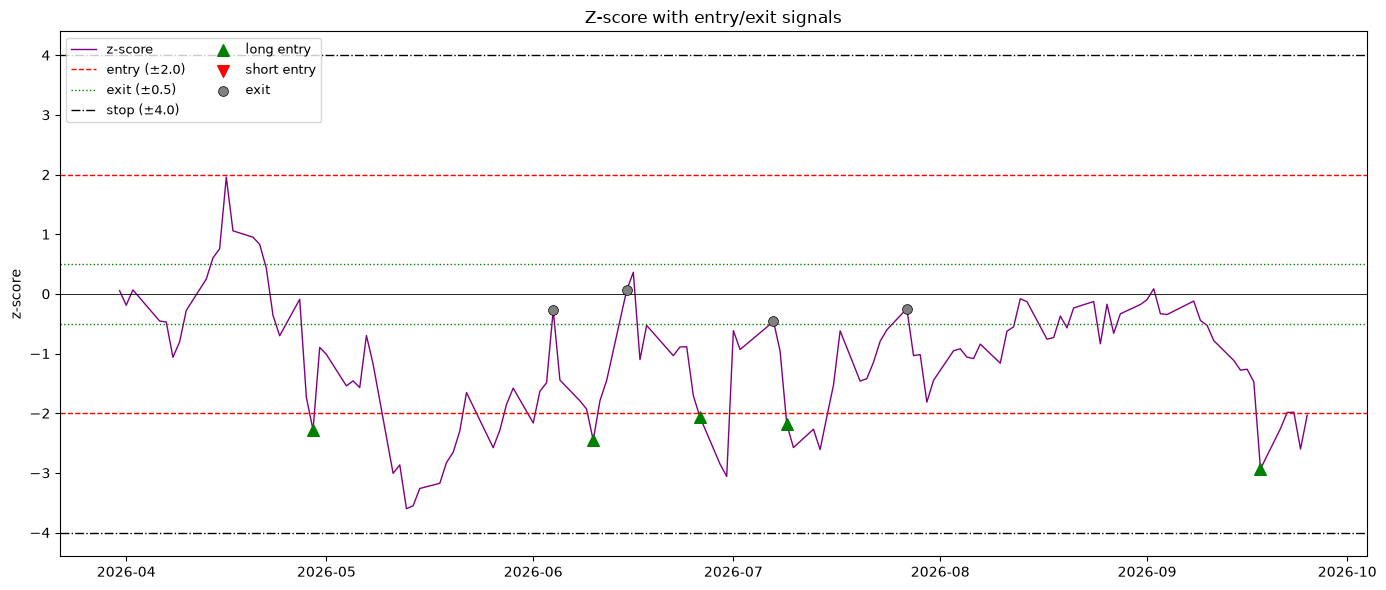

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, z, color="purple", lw=1.0, label="z-score", zorder=2)
ax.axhline(0, color="black", lw=0.6)
ax.axhline(entry, color="red", ls="--", lw=1, label=f"entry (±{entry})")
ax.axhline(-entry, color="red", ls="--", lw=1)
ax.axhline(exit_, color="green", ls=":", lw=1, label=f"exit (±{exit_})")
ax.axhline(-exit_, color="green", ls=":", lw=1)
if stop is not None:
    ax.axhline(stop, color="black", ls="-.", lw=1, label=f"stop (±{stop})")
    ax.axhline(-stop, color="black", ls="-.", lw=1)

long_entry_idx = np.where((trade == 1) & (position == 1))[0]
short_entry_idx = np.where((trade == -1) & (position == -1))[0]
exit_idx = np.where((trade != 0) & (position == 0))[0]

ax.scatter(dates[long_entry_idx], z[long_entry_idx], marker="^", color="green",
           s=70, zorder=5, label="long entry")
ax.scatter(dates[short_entry_idx], z[short_entry_idx], marker="v", color="red",
           s=70, zorder=5, label="short entry")
ax.scatter(dates[exit_idx], z[exit_idx], marker="o", color="gray",
           s=50, zorder=5, label="exit", edgecolors="black", linewidths=0.5)

ax.set_title("Z-score with entry/exit signals")
ax.set_ylabel("z-score")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()